# Creating and Backtesting simple Momentum/Contrarian Strategies

## Getting the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [2]:
data = pd.read_csv("eurusd1H.csv", parse_dates=['time'], index_col='time')

In [3]:
data.head()

,c
time,
2024-01-01 22:00:00,1.10438
2024-01-01 23:00:00,1.10359
2024-01-02 00:00:00,1.10375
2024-01-02 01:00:00,1.10343
2024-01-02 02:00:00,1.10181


In [ ]:
data.info()

In [ ]:
data.plot(figsize = (12, 8), title = "EUR/USD", fontsize = 12)
plt.show()

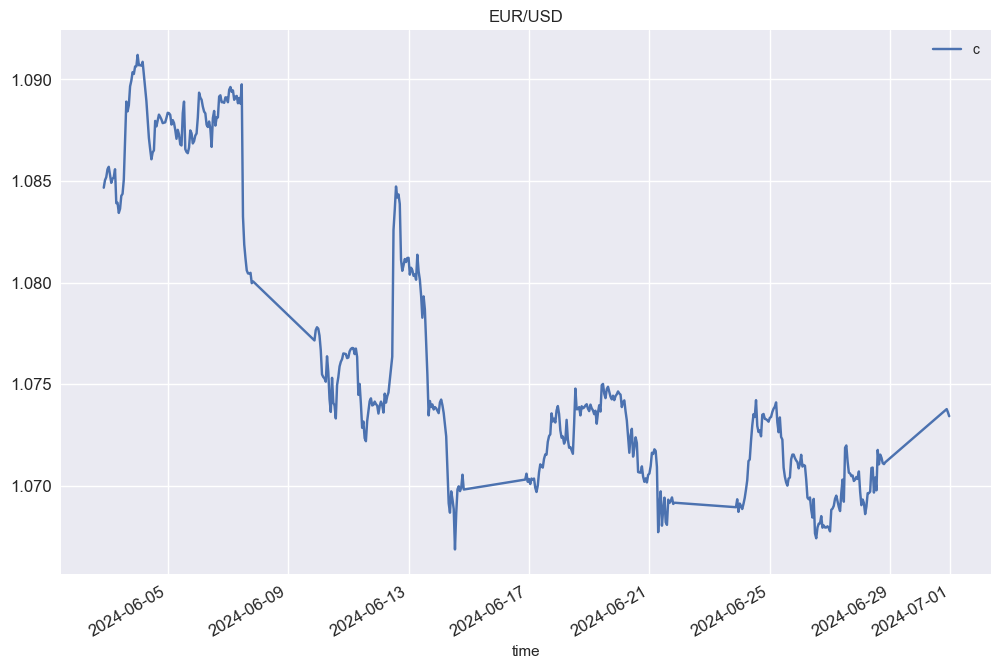

In [14]:
data.loc["2024-06", ['c']].plot(figsize = (12, 8), title = "EUR/USD", fontsize = 12)
plt.show()

In [4]:
data["returns"] = np.log(data.div(data.shift(1)))

In [5]:
data.dropna(inplace = True)

In [6]:
data.head()

,c,returns
time,,
2024-01-01 23:00:00,1.10359,-0.000716
2024-01-02 00:00:00,1.10375,0.000145
2024-01-02 01:00:00,1.10343,-0.000290
2024-01-02 02:00:00,1.10181,-0.001469
2024-01-02 03:00:00,1.10239,0.000526


## Defining a simple Contrarian Strategy (window = 3)

In [8]:
window = 3

In [ ]:
data

In [9]:
data["returns"].rolling(window).mean()

time
2024-01-01 23:00:00         NaN
2024-01-02 00:00:00         NaN
2024-01-02 01:00:00   -0.000287
2024-01-02 02:00:00   -0.000538
2024-01-02 03:00:00   -0.000411
                         ...   
2025-12-30 18:00:00   -0.000286
2025-12-30 19:00:00   -0.000510
2025-12-30 20:00:00   -0.000343
2025-12-30 21:00:00   -0.000054
2025-12-30 22:00:00   -0.000017
Name: returns, Length: 12430, dtype: float64

In [10]:
data["position"] = -np.sign(data["returns"].rolling(window).mean()) # contrarian (minus sign)

In [11]:
data.head()

,c,returns,position
time,,,
2024-01-01 23:00:00,1.10359,-0.000716,NaN
2024-01-02 00:00:00,1.10375,0.000145,NaN
2024-01-02 01:00:00,1.10343,-0.000290,1.0
2024-01-02 02:00:00,1.10181,-0.001469,1.0
2024-01-02 03:00:00,1.10239,0.000526,1.0


In [ ]:
data.dropna(inplace=True)

## Vectorized Strategy Backtesting

In [12]:
data["strategy"] = data.position.shift(1) * data["returns"]

In [ ]:
data.dropna(inplace = True)

In [ ]:
data

In [13]:
data[["returns", "strategy"]].sum()

returns     0.061592
strategy    0.186067
dtype: float64

In [ ]:
data[["returns", "strategy"]].sum().apply(np.exp)

In [ ]:
data["creturns"] = data["returns"].cumsum().apply(np.exp)
data["cstrategy"] = data["strategy"].cumsum().apply(np.exp)

In [ ]:
data

In [ ]:
data[["creturns", "cstrategy"]].plot(figsize = (12 , 8),
                                     title = "EUR/USD | Window = {}".format(window), fontsize = 12)
plt.show()

## Changing the window parameter

In [ ]:
data = pd.read_csv("intraday.csv", parse_dates = ["time"], index_col = "time")

In [ ]:
data

In [ ]:
data["returns"] = np.log(data.div(data.shift(1)))

In [ ]:
data.dropna(inplace = True)
data

In [ ]:
to_plot = ["returns"]

In [ ]:
for w in [1, 2, 3, 5, 10]:
    data["position{}".format(w)] = -np.sign(data["returns"].rolling(w).mean())
    data["strategy{}".format(w)] = data["position{}".format(w)].shift(1) * data["returns"]
    to_plot.append("strategy{}".format(w))

In [ ]:
data

In [ ]:
to_plot

In [ ]:
data[to_plot].dropna().cumsum().apply(np.exp).plot(figsize = (12, 8))
plt.title("DJI Intraday - 6h bars", fontsize = 12)
plt.legend(fontsize = 12)
plt.show()

In [ ]:
data

## Trades and Trading Costs (Part 1)

In [ ]:
data = pd.read_csv("intraday.csv", parse_dates = ["time"], index_col = "time")

In [ ]:
window = 3

In [ ]:
data["returns"] = np.log(data.div(data.shift(1)))

In [ ]:
data["position"] = -np.sign(data["returns"].rolling(window).mean())

In [ ]:
data["strategy"] = data.position.shift(1) * data["returns"]

In [ ]:
data

In [ ]:
data.dropna(inplace = True)

In [ ]:
data["creturns"] = data["returns"].cumsum().apply(np.exp)
data["cstrategy"] = data["strategy"].cumsum().apply(np.exp)

In [ ]:
data

In [ ]:
data.loc[:, "position"].plot(figsize = (12 , 8))
plt.show()

In [ ]:
data.loc["2019-06", "position"].plot(figsize = (12 , 8))
plt.show()

__Trading/Transaction Costs__ (simplified)

In [ ]:
spread = 1.5 * 0.0001 # pips == fourth price decimal
spread

In [ ]:
half_spread = spread / 2 # absolute tc per trade (position change +-1)
half_spread

In [ ]:
ptc = half_spread / data.price.mean() # proportional tc per trade (position change +-1)
ptc

In [ ]:
ptc = 0.00007

In [ ]:
data

In [ ]:
data.position.diff().fillna(0).abs()

In [ ]:
data["trades"] = data.position.diff().fillna(0).abs()

In [ ]:
data

In [ ]:
data.trades.value_counts()

## Trades and Trading Costs (Part 2)

In [ ]:
data

In [ ]:
data["strategy_net"] = data.strategy - data.trades * ptc

In [ ]:
data["cstrategy_net"] = data.strategy_net.cumsum().apply(np.exp)

In [ ]:
data

In [ ]:
data[["creturns", "cstrategy", "cstrategy_net"]].plot(figsize = (12 , 8))
plt.show()